## Traversal plot

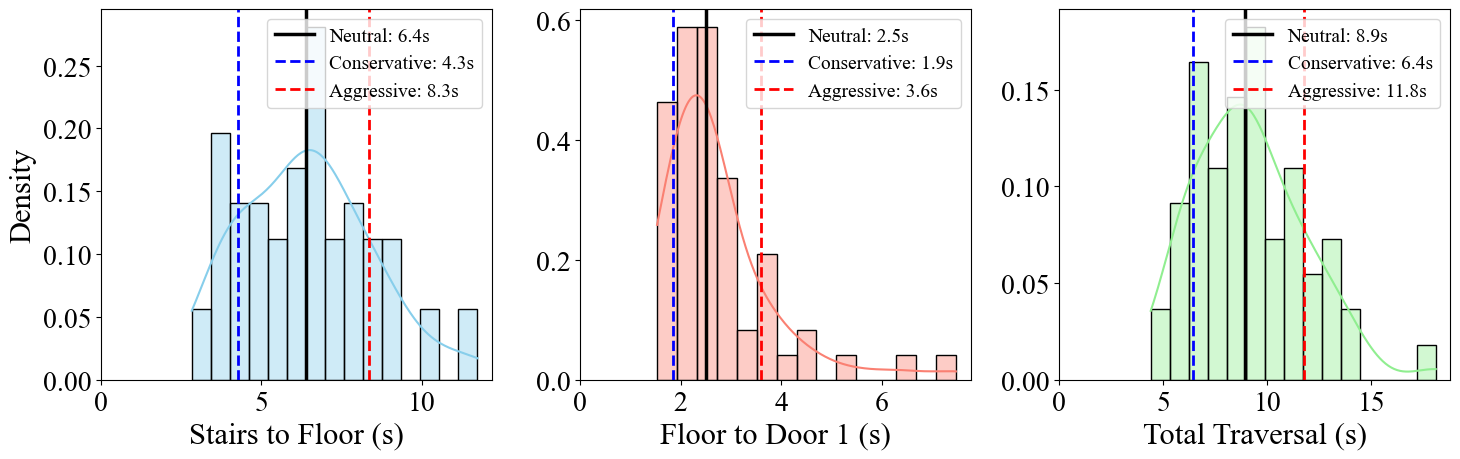

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. Configuration (Academic Style)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams.update({'font.size': 20}) 

# ==========================================
# 2. Load and Prepare Data
# ==========================================
# Assuming 'descending_passengers.csv' is in your workspace
df = pd.read_csv('descending_passengers.csv', sep='\t')
df_filtered = df[df['특징(door2는 제외)'] != 'door2'].copy()
df_filtered['Total Time'] = df_filtered['stairs --> floor [s]'] + df_filtered['floor -> psd [s]']

# ==========================================
# 3. Plotting
# ==========================================
cols = ["stairs --> floor [s]", "floor -> psd [s]", "Total Time"]
x_labels = ["Stairs to Floor (s)", "Floor to Door 1 (s)", "Total Traversal (s)"]
colors = ['skyblue', 'salmon', 'lightgreen']

# Compact figure size optimized for IEEE double-column width
plt.figure(figsize=(15, 5)) 

for i, col in enumerate(cols):
    plt.subplot(1, 3, i+1)
    
    # Calculate Statistics (Percentiles)
    p16 = np.percentile(df_filtered[col], 15.8) 
    median_val = np.percentile(df_filtered[col], 50)
    p84 = np.percentile(df_filtered[col], 84.2)
    
    # Strategy Mapping: 
    # Aggressive = Slower/Longer Time (P84) -> System works harder for safety
    # Conservative = Faster/Shorter Time (P16)
    aggressive = p84   
    neutral = median_val
    conservative = p16  
    
    # Plot Distribution
    sns.histplot(df_filtered[col], kde=True, color=colors[i], 
                 stat="density", bins=15, alpha=0.4) 
    
    # Mark the 3 Strategies
    plt.axvline(neutral, color='black', linestyle='-', linewidth=2.5, 
                label=f'Neutral: {neutral:.1f}s')
    
    plt.axvline(conservative, color='blue', linestyle='--', linewidth=2, 
                label=f'Conservative: {conservative:.1f}s')
    
    plt.axvline(aggressive, color='red', linestyle='--', linewidth=2, 
                label=f'Aggressive: {aggressive:.1f}s')
    
    # Axis & Legend Formatting
    plt.xlim(left=0) # Force X-axis to start at 0
    plt.xlabel(x_labels[i], fontsize=22)
    plt.ylabel('Density' if i == 0 else '', fontsize=22)
    
    # Increased legend size for better legibility in small figures
    plt.legend(prop={'size': 14}, loc='upper right', frameon=True)
    plt.title("") 

plt.tight_layout()
# plt.savefig('traversal_distribution_final.png', dpi=300, bbox_inches='tight')
plt.show()

## Velocity plots

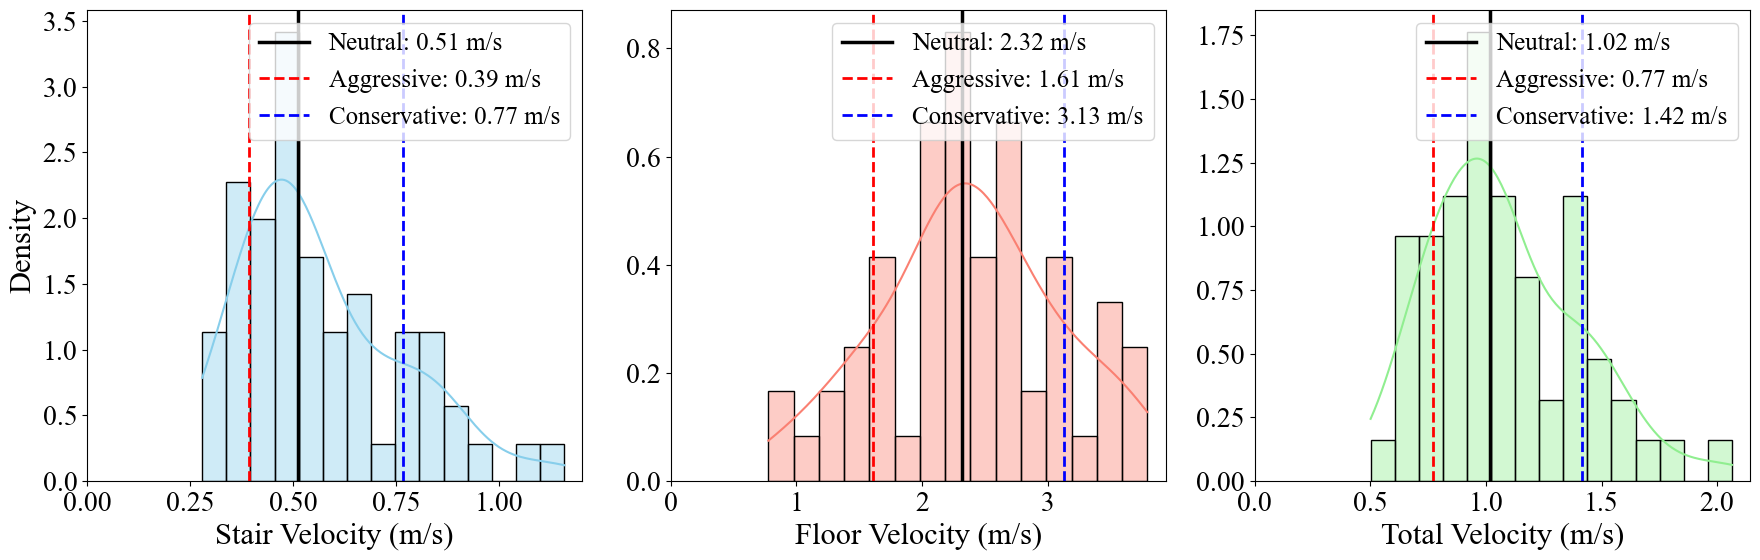

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. Configuration (Academic Style)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams.update({'font.size': 20}) 

# ==========================================
# 2. Data Preparation
# ==========================================
DIST_STAIR = 3.28  # Meters
DIST_FLOOR = 5.8   # Meters

df = pd.read_csv('descending_passengers.csv', sep='\t')
df_filtered = df[df['특징(door2는 제외)'] != 'door2'].copy()

# Calculate Velocity (v = d/t)
df_filtered['v_stair'] = DIST_STAIR / df_filtered['stairs --> floor [s]']
df_filtered['v_floor'] = DIST_FLOOR / df_filtered['floor -> psd [s]']
# Total path velocity
df_filtered['v_total'] = (DIST_STAIR + DIST_FLOOR) / (df_filtered['stairs --> floor [s]'] + df_filtered['floor -> psd [s]'])

# ==========================================
# 3. Plotting: Velocity vs PDF
# ==========================================
cols = ["v_stair", "v_floor", "v_total"]
x_labels = ["Stair Velocity (m/s)", "Floor Velocity (m/s)", "Total Velocity (m/s)"]
colors = ['skyblue', 'salmon', 'lightgreen']

# Figure sized for clear visibility in IEEE format
plt.figure(figsize=(18, 6)) 

for i, col in enumerate(cols):
    plt.subplot(1, 3, i+1)
    
    # Calculate Statistics (Percentiles on Velocity)
    p16 = np.percentile(df_filtered[col], 15.8) 
    median_val = np.percentile(df_filtered[col], 50)
    p84 = np.percentile(df_filtered[col], 84.2)
    
    # Label Logic: 
    # Aggressive = Slower speed (System needs higher safety/open time)
    # Conservative = Faster speed
    aggressive = p16  
    neutral = median_val
    conservative = p84  
    
    # Plotting
    sns.histplot(df_filtered[col], kde=True, color=colors[i], stat="density", bins=15, alpha=0.4) 
    
    # Strategy Lines
    plt.axvline(neutral, color='black', linestyle='-', linewidth=2.5, 
                label=f'Neutral: {neutral:.2f} m/s')
    plt.axvline(aggressive, color='red', linestyle='--', linewidth=2, 
                label=f'Aggressive: {aggressive:.2f} m/s')
    plt.axvline(conservative, color='blue', linestyle='--', linewidth=2, 
                label=f'Conservative: {conservative:.2f} m/s')
    
    # Formatting
    plt.xlim(left=0)
    plt.xlabel(x_labels[i], fontsize=22)
    plt.ylabel('Density' if i == 0 else '', fontsize=22)
    plt.legend(prop={'size': 18}, loc='upper right')
    plt.title("") 

plt.tight_layout()
plt.show()

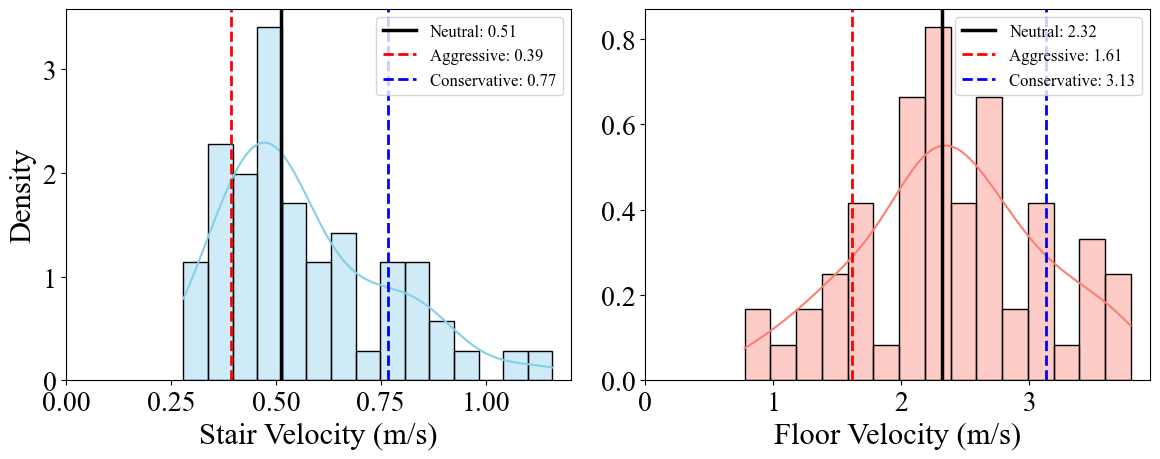

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configuration ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams.update({'font.size': 20}) 

# Constants
DIST_STAIR = 3.28  
DIST_FLOOR = 5.8   

df = pd.read_csv('descending_passengers.csv', sep='\t')
df_filtered = df[df['특징(door2는 제외)'] != 'door2'].copy()

# Calculations
df_filtered['v_stair'] = DIST_STAIR / df_filtered['stairs --> floor [s]']
df_filtered['v_floor'] = DIST_FLOOR / df_filtered['floor -> psd [s]']

cols = ["v_stair", "v_floor"]
x_labels = ["Stair Velocity (m/s)", "Floor Velocity (m/s)"]
colors = ['skyblue', 'salmon']

plt.figure(figsize=(12, 5)) 

for i, col in enumerate(cols):
    plt.subplot(1, 2, i+1)
    
    # Stats
    aggressive = np.percentile(df_filtered[col], 15.8) # Slow
    neutral = np.percentile(df_filtered[col], 50)     # Median
    conservative = np.percentile(df_filtered[col], 84.2) # Fast
    
    sns.histplot(df_filtered[col], kde=True, color=colors[i], stat="density", bins=15, alpha=0.4) 
    
    plt.axvline(neutral, color='black', linestyle='-', linewidth=2.5, label=f'Neutral: {neutral:.2f}')
    plt.axvline(aggressive, color='red', linestyle='--', linewidth=2, label=f'Aggressive: {aggressive:.2f}')
    plt.axvline(conservative, color='blue', linestyle='--', linewidth=2, label=f'Conservative: {conservative:.2f}')
    
    plt.xlim(left=0)
    plt.xlabel(x_labels[i], fontsize=22)
    plt.ylabel('Density' if i == 0 else '', fontsize=22)
    plt.legend(prop={'size': 12}, loc='upper right')

plt.tight_layout()
plt.show()

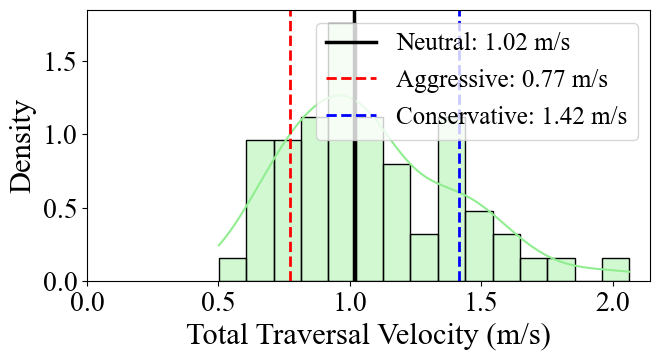

In [19]:
# Separate Plot for Total Velocity
plt.figure(figsize=(7, 4)) 

# Total Distance / Total Time
df_filtered['v_total'] = (DIST_STAIR + DIST_FLOOR) / (df_filtered['stairs --> floor [s]'] + df_filtered['floor -> psd [s]'])

col = "v_total"
aggressive = np.percentile(df_filtered[col], 15.8) 
neutral = np.percentile(df_filtered[col], 50)
conservative = np.percentile(df_filtered[col], 84.2)

sns.histplot(df_filtered[col], kde=True, color='lightgreen', stat="density", bins=15, alpha=0.4) 

plt.axvline(neutral, color='black', linestyle='-', linewidth=2.5, label=f'Neutral: {neutral:.2f} m/s')
plt.axvline(aggressive, color='red', linestyle='--', linewidth=2, label=f'Aggressive: {aggressive:.2f} m/s')
plt.axvline(conservative, color='blue', linestyle='--', linewidth=2, label=f'Conservative: {conservative:.2f} m/s')

plt.xlim(left=0)
plt.xlabel("Total Traversal Velocity (m/s)", fontsize=22)
plt.ylabel('Density', fontsize=22)
plt.legend(prop={'size': 18}, loc='upper right')

plt.tight_layout()
plt.show()